# `Мультилейбл датасеты`

- размеры датасетов
- число классов
- баланс классов на трейне и тесте
- какие классы встречаются друг с другом (граф + наиболее частые сочетания)
- распределение длин
- качество logreg+tfidf
- посмотреть на выбросы по длине

отдельно посмотреть oos и multilabel датасеты

In [1]:
single_label_datasets = ["DeepPavlov/banking77", "DeepPavlov/minds14", "DeepPavlov/hwu64", "DeepPavlov/snips", "DeepPavlov/massive"]
multi_label_datasets = ["DeepPavlov/events", "DeepPavlov/dstc3", "DeepPavlov/reuters", "DeepPavlov/eurlex"]
oos_datasets = ["DeepPavlov/clinc150"]

In [2]:
tokenizers_names = ["answerdotai/ModernBERT-base", "google-bert/bert-base-uncased", "openai-community/gpt2", "Qwen/QwQ-32B"]

In [3]:
import datasets
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import numpy as np

sns.set_style("whitegrid")

## `Баланс классов`

In [13]:
def get_number_of_classes(ds: datasets.Dataset):
    return len(ds["label"][0])

In [5]:
def plot_class_balance(repo_name):
    # Load the dataset from Hugging Face
    dataset = datasets.load_dataset(repo_name)
    
    # Initialize dictionaries to count the occurrences of each class for train and test sets
    train_class_counts = {}
    test_class_counts = {}
    
    # Count class occurrences in the train set
    for sample in dataset['train']:
        labels = sample['label']
        for i, label in enumerate(labels):
            if i not in train_class_counts:
                train_class_counts[i] = 0
            if label == 1:
                train_class_counts[i] += 1
    
    # Count class occurrences in the test set
    for sample in dataset['test']:
        labels = sample['label']
        for i, label in enumerate(labels):
            if i not in test_class_counts:
                test_class_counts[i] = 0
            if label == 1:
                test_class_counts[i] += 1
    
    # Calculate the fraction of samples belonging to each class for train and test sets
    train_total_samples = len(dataset['train'])
    test_total_samples = len(dataset['test'])
    
    train_class_fractions = {cls: count / train_total_samples for cls, count in train_class_counts.items()}
    test_class_fractions = {cls: count / test_total_samples for cls, count in test_class_counts.items()}
    
    # Get the classes and their fractions
    classes = sorted(train_class_fractions.keys())
    train_fractions = [train_class_fractions[cls] for cls in classes]
    test_fractions = [test_class_fractions[cls] for cls in classes]
    
    # Plot the bar plot
    x = np.arange(len(classes))  # the label locations
    width = 0.35  # the width of the bars
    
    plt.figure(figsize=(12, 3))
    train_bars = plt.bar(x - width/2, train_fractions, width, label='Train', color='blue')
    test_bars = plt.bar(x + width/2, test_fractions, width, label='Test', color='orange')
    
    # Add text annotations on top of each bar
    for bars, fractions in zip([train_bars, test_bars], [train_fractions, test_fractions]):
        for bar, fraction in zip(bars, fractions):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height, f'{fraction:.2f}', 
                     ha='center', va='bottom', fontsize=10)
    
    # Add labels, title, and legend
    plt.xlabel('Class')
    plt.ylabel('Fraction of Samples')
    plt.title(f'Class Balance for {repo_name}')
    plt.xticks(x, classes)
    plt.legend()
    plt.show()

In [6]:
def plot_all_class_balances(datasets_names: list[str]):
    for name in datasets_names:
        plot_class_balance(name)

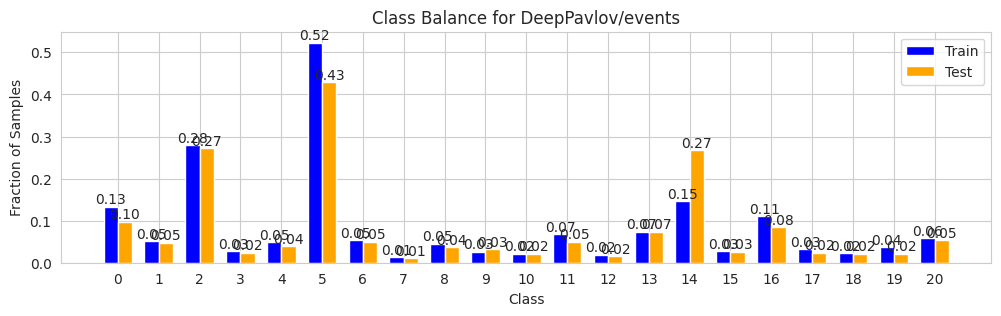

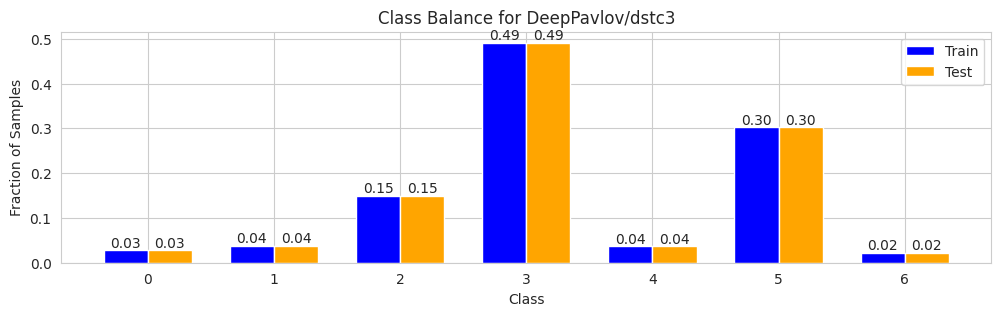

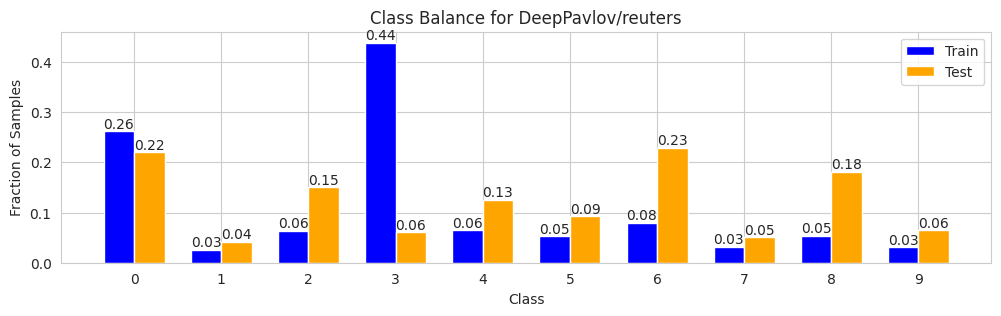

README.md:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/161M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/23.1M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/15.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/53203 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4774 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4834 [00:00<?, ? examples/s]

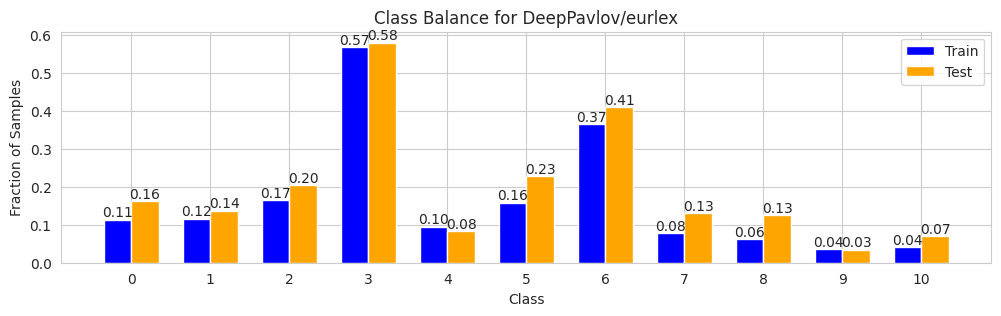

In [7]:
plot_all_class_balances(multi_label_datasets)

## `Размеры датасетов`

In [4]:
def plot_datasets_sizes(datasets_names: list[str]):
    train_sizes = []
    test_sizes = []
    
    for name in datasets_names:
        ds = datasets.load_dataset(name)
        train_size = len(ds['train'])
        test_size = len(ds['test'])
        train_sizes.append(train_size)
        test_sizes.append(test_size)
    
    # Plotting
    x = range(len(datasets_names))
    width = 0.35  # Width of the bars
    
    fig, ax = plt.subplots()
    rects1 = ax.bar([i - width/2 for i in x], train_sizes, width, label='Train')
    rects2 = ax.bar([i + width/2 for i in x], test_sizes, width, label='Test')
    
    # Add some text for labels, title, and custom x-axis tick labels, etc.
    ax.set_xlabel('Datasets')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Train and Test Sizes of Datasets')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets_names, rotation=30, ha='right')
    ax.legend()
    
    # Add counts on top of the bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    autolabel(rects1)
    autolabel(rects2)
    
    fig.tight_layout()
    plt.show()


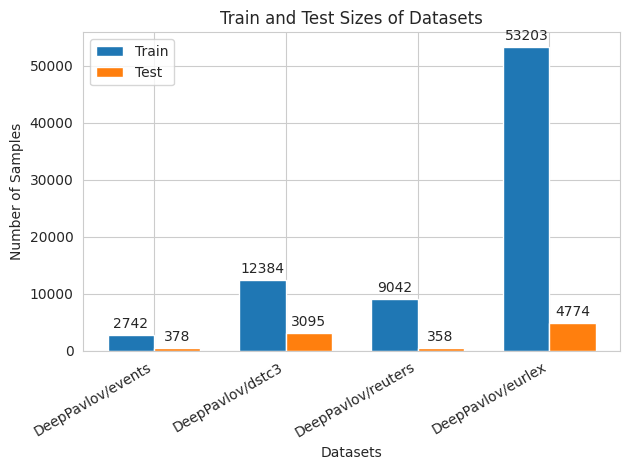

In [5]:
plot_datasets_sizes(multi_label_datasets)

## `Длины датасетов`

In [6]:
def plot_tokens_distributions(datasets_names: list[str], tokenizer_name: str):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    for name in datasets_names:
        ds = datasets.load_dataset(name)
        
        # Tokenize the text and count the number of tokens
        n_tokens_train = [len(tokenizer.encode(rec["utterance"])) for rec in ds["train"]]
        n_tokens_test = [len(tokenizer.encode(rec["utterance"])) for rec in ds["test"]]
        
        # Create a figure and axis
        plt.figure(figsize=(5, 3))
        plt.title(f"Token Length Distribution for {name}")
        plt.xlabel("Number of Tokens")
        plt.ylabel("Density")
        
        # Plot the histograms
        sns.histplot(n_tokens_train, kde=True, color="blue", label="Train", stat="density", common_norm=False)
        sns.histplot(n_tokens_test, kde=True, color="orange", label="Test", stat="density", common_norm=False)
        
        # Add a legend
        plt.legend()
        
        # Show the plot
        plt.show()

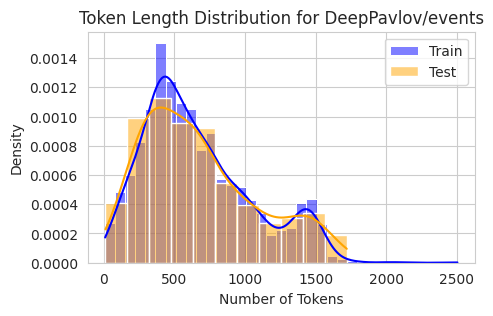

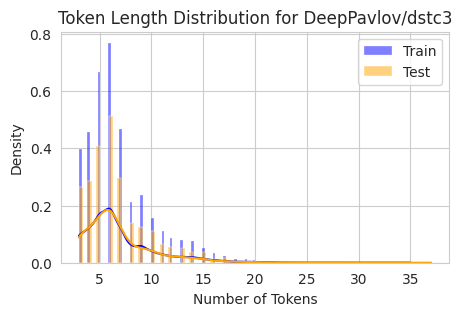

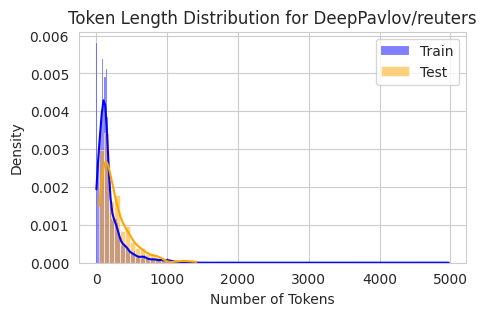

Token indices sequence length is longer than the specified maximum sequence length for this model (8690 > 8192). Running this sequence through the model will result in indexing errors


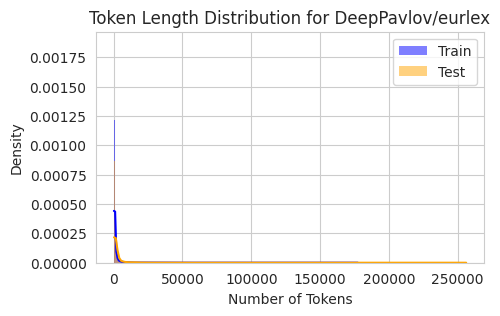

In [7]:
plot_tokens_distributions(multi_label_datasets, tokenizers_names[0])

In [8]:
def plot_average_tokens(datasets_names: list[str], tokenizers_names: list[str]):
    for name in datasets_names:
        ds = datasets.load_dataset(name)
        
        # Initialize lists to store the average token lengths and their stds
        avg_train_tokens = []
        avg_test_tokens = []
        std_train_tokens = []
        std_test_tokens = []
        
        for tokenizer_name in tokenizers_names:
            tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
            
            # Calculate the number of tokens for train and test sets
            n_tokens_train = [len(tokenizer.encode(rec["utterance"])) for rec in ds["train"]]
            n_tokens_test = [len(tokenizer.encode(rec["utterance"])) for rec in ds["test"]]
            
            # Compute the average and standard deviation
            avg_train_tokens.append(np.mean(n_tokens_train))
            avg_test_tokens.append(np.mean(n_tokens_test))
            std_train_tokens.append(np.std(n_tokens_train))
            std_test_tokens.append(np.std(n_tokens_test))
        
        # Plotting
        x = np.arange(len(tokenizers_names))
        width = 0.35
        
        plt.bar(x - width/2, avg_train_tokens, width, label='Train', yerr=std_train_tokens, capsize=5)
        plt.bar(x + width/2, avg_test_tokens, width, label='Test', yerr=std_test_tokens, capsize=5)
        
        plt.xlabel('Tokenizers')
        plt.ylabel('Average Number of Tokens')
        plt.title(f'Dataset: {name}')
        plt.xticks(x, tokenizers_names, rotation=30)
        plt.legend()
        
        # Show the plot for the current dataset
        plt.show()

Token indices sequence length is longer than the specified maximum sequence length for this model (928 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1052 > 1024). Running this sequence through the model will result in indexing errors


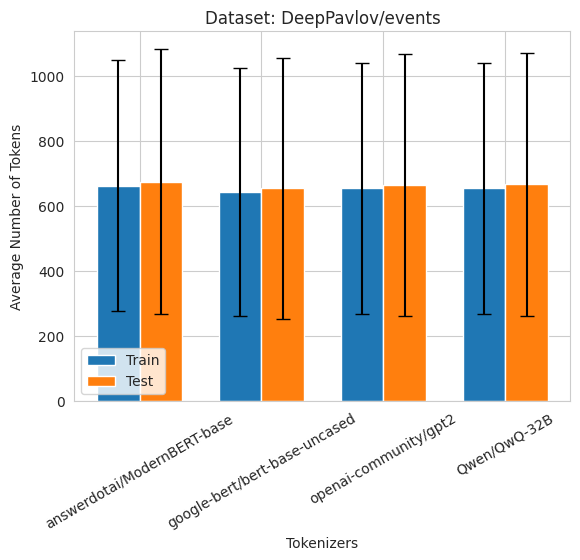

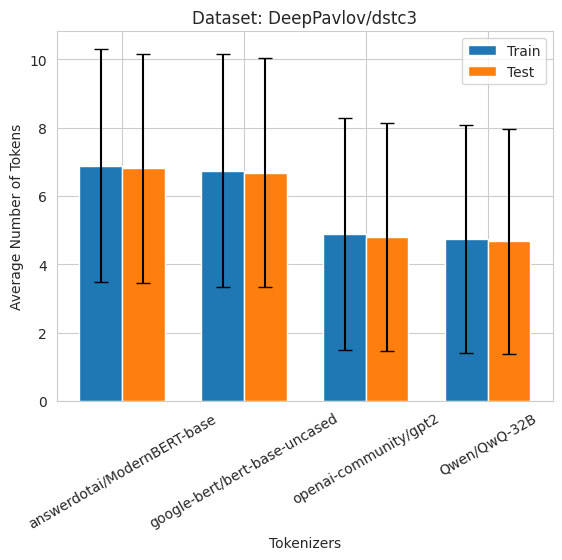

Token indices sequence length is longer than the specified maximum sequence length for this model (568 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1274 > 1024). Running this sequence through the model will result in indexing errors


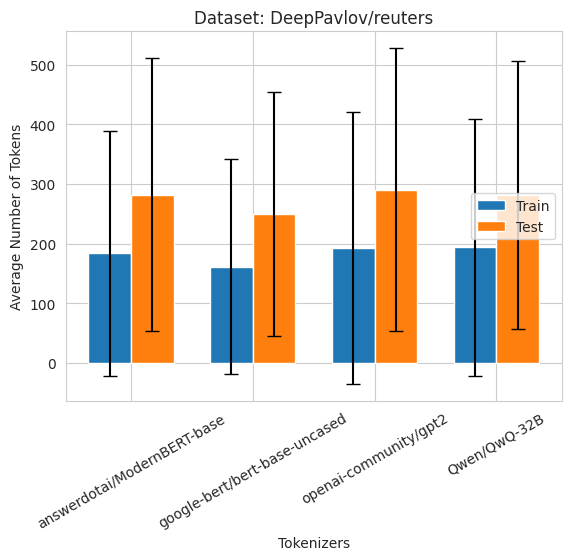

Token indices sequence length is longer than the specified maximum sequence length for this model (8690 > 8192). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (637 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (3659 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (138093 > 131072). Running this sequence through the model will result in indexing errors


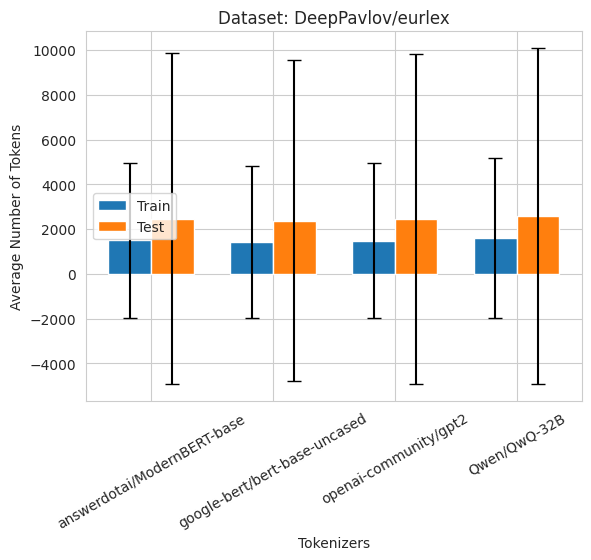

In [10]:
plot_average_tokens(multi_label_datasets, tokenizers_names)

## `Длины в каждом классе`

In [14]:
def plot_classwise_average_tokens(datasets_names: list[str], tokenizer_name: str):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    for name in datasets_names:
        ds = datasets.load_dataset(name)
        
        # Initialize lists to store the average token lengths and their stds
        avg_train_tokens = []
        avg_test_tokens = []
        std_train_tokens = []
        std_test_tokens = []
        
        n_classes = get_number_of_classes(ds["train"])
        for i in range(n_classes):

            # Calculate the number of tokens for train and test sets
            n_tokens_train = [len(tokenizer.encode(rec["utterance"])) for rec in ds["train"] if rec["label"][i] == 1]
            n_tokens_test = [len(tokenizer.encode(rec["utterance"])) for rec in ds["test"] if rec["label"][i] == 1]
            
            # Compute the average and standard deviation
            avg_train_tokens.append(np.mean(n_tokens_train))
            avg_test_tokens.append(np.mean(n_tokens_test))
            std_train_tokens.append(np.std(n_tokens_train))
            std_test_tokens.append(np.std(n_tokens_test))
        
        # Plotting
        x = np.arange(n_classes)
        width = 0.35
        
        plt.figure(figsize=(15,4))
        plt.bar(x - width/2, avg_train_tokens, width, label='Train', yerr=std_train_tokens, capsize=5)
        plt.bar(x + width/2, avg_test_tokens, width, label='Test', yerr=std_test_tokens, capsize=5)
        
        plt.xlabel('Classes')
        plt.ylabel('Average Number of Tokens')
        plt.title(f'Dataset: {name}')
        plt.xticks(x)
        plt.legend()
        
        # Show the plot for the current dataset
        plt.show()

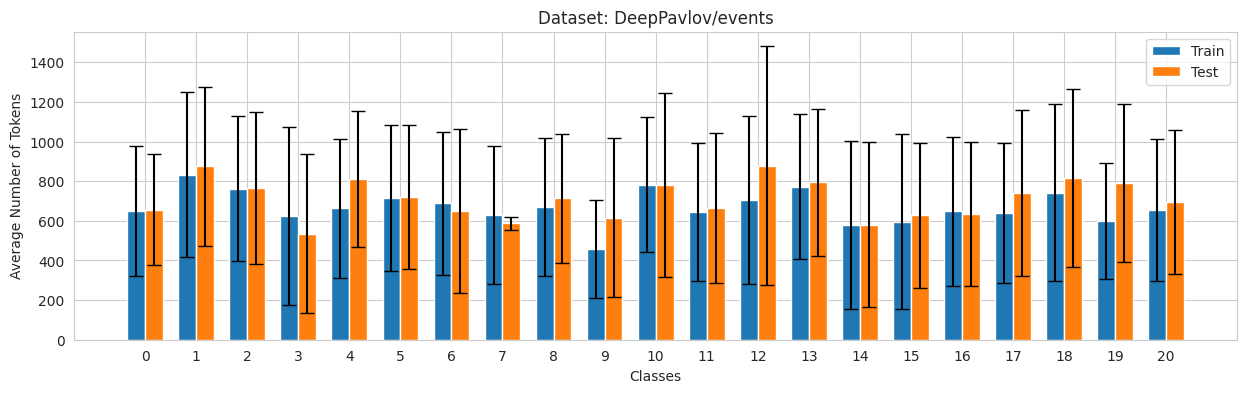

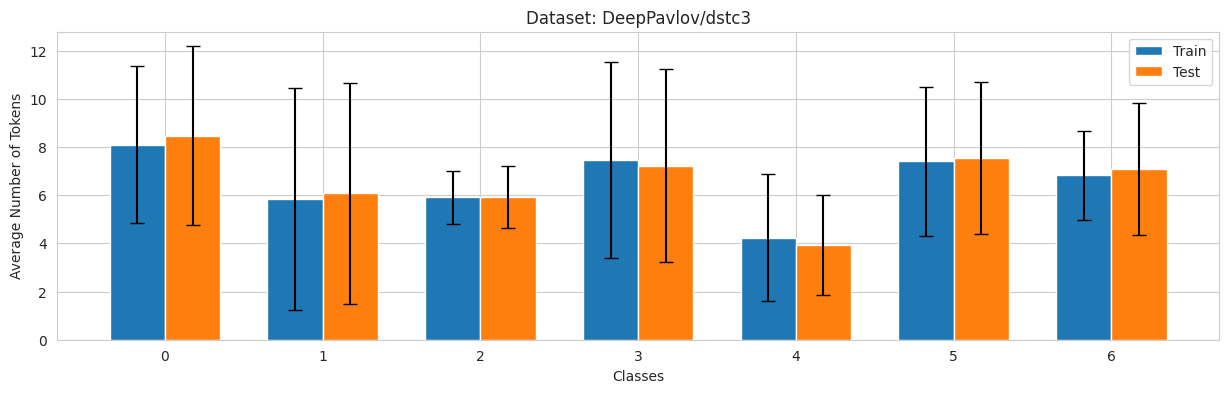

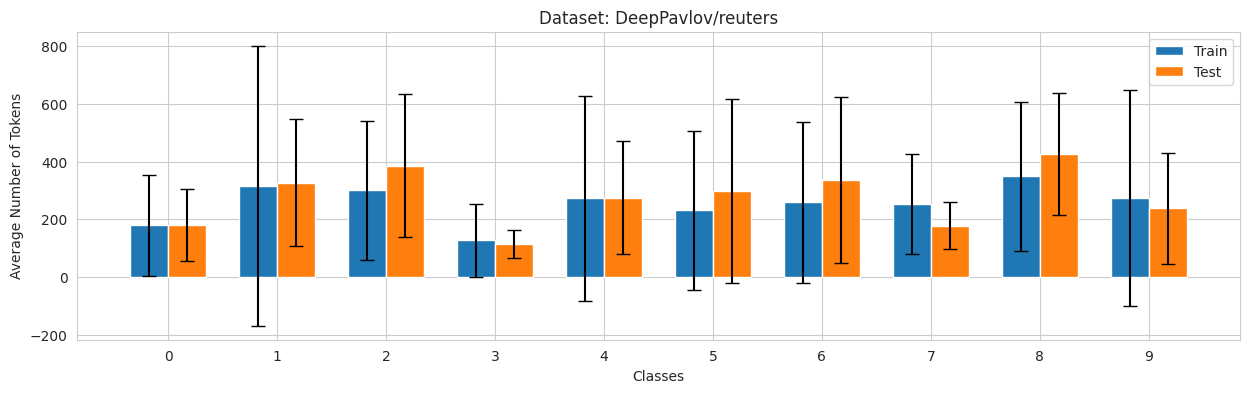

Token indices sequence length is longer than the specified maximum sequence length for this model (13398 > 8192). Running this sequence through the model will result in indexing errors


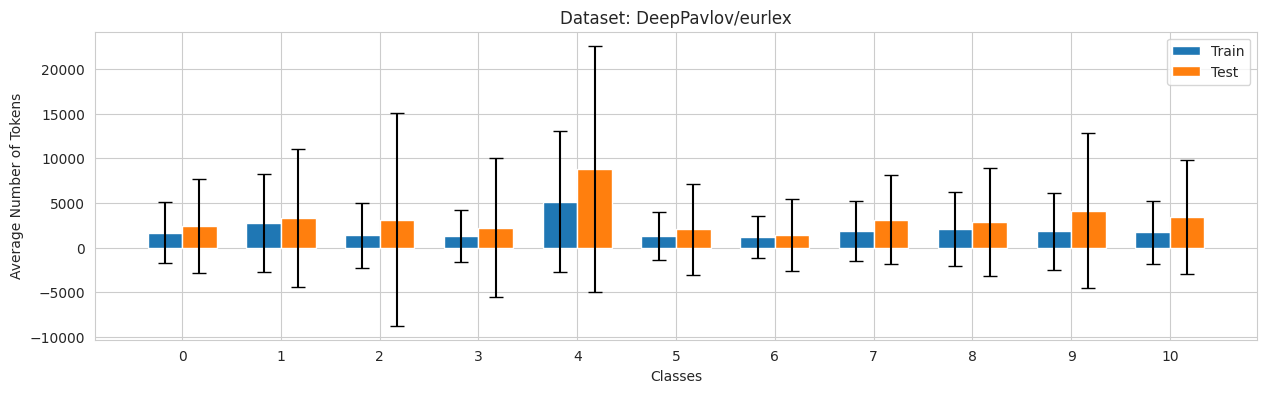

In [15]:
plot_classwise_average_tokens(multi_label_datasets, tokenizers_names[0])

## `Выбросы по длинам`

In [16]:
def _find_outliers(dataset_name: str, tokenizer_name: str, k: int = 3):
    # Load the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    
    # Load the dataset
    ds = datasets.load_dataset(dataset_name)
    
    # Tokenize the texts and count the number of tokens
    n_tokens_train = [len(tokenizer.encode(rec["utterance"])) for rec in ds["train"]]
    n_tokens_test = [len(tokenizer.encode(rec["utterance"])) for rec in ds["test"]]
    
    # Combine train and test tokens for analysis
    all_n_tokens = n_tokens_train + n_tokens_test
    all_texts = [rec["utterance"] for rec in ds["train"]] + [rec["utterance"] for rec in ds["test"]]
    
    # Sort texts based on the number of tokens
    sorted_indices = np.argsort(all_n_tokens)
    sorted_texts = [all_texts[i] for i in sorted_indices]
    sorted_n_tokens = [all_n_tokens[i] for i in sorted_indices]
    
    # Find k shortest texts
    k_shortest_texts = sorted_texts[:k]
    k_shortest_tokens = sorted_n_tokens[:k]
    
    # Find k longest texts
    k_longest_texts = sorted_texts[-k:]
    k_longest_tokens = sorted_n_tokens[-k:]
    
    # Find k texts around the median
    median_index = len(sorted_texts) // 2
    k_median_texts = sorted_texts[median_index - k//2 : median_index + k//2 + 1]
    k_median_tokens = sorted_n_tokens[median_index - k//2 : median_index + k//2 + 1]
    
    # Print the results
    print(f"{k} Shortest Texts:")
    for text, tokens in zip(k_shortest_texts, k_shortest_tokens):
        print(f"Tokens: {tokens}, Text: {text}")
    
    print(f"\n{k} Longest Texts:")
    for text, tokens in zip(k_longest_texts, k_longest_tokens):
        print(f"Tokens: {tokens}, Text: {text}")
    
    print(f"\n{k} Texts Around the Median:")
    for text, tokens in zip(k_median_texts, k_median_tokens):
        print(f"Tokens: {tokens}, Text: {text}")


In [17]:
def find_outliers(datasets_names: list[str], tokenizer_name: str, k: int = 3):
    for name in datasets_names:
        print(f"==== {name} ====", end="\n\n")
        _find_outliers(name, tokenizer_name, k)
        print()

In [ ]:
find_outliers(multi_label_datasets, tokenizers_names[0], k=3)

==== DeepPavlov/events ====



## `Бейзлайн`

In [45]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
)
from tabulate import tabulate

def check_baseline(datasets_names: list[str]):
    # Initialize a dictionary to store metrics for each dataset
    results = []

    for name in datasets_names:
        ds = datasets.load_dataset(name)
        train_utterances = ds["train"]["utterance"]
        test_utterances = ds["test"]["utterance"]
        train_labels = ds["train"]["label"]
        test_labels = ds["test"]["label"]
        
        # TF-IDF Vectorization
        vectorizer = TfidfVectorizer()
        X_train = vectorizer.fit_transform(train_utterances)
        X_test = vectorizer.transform(test_utterances)
        
        # Logistic Regression with Cross-Validation
        model = LogisticRegressionCV(cv=3, max_iter=300)
        model.fit(X_train, train_labels)
        
        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(test_labels, y_pred)
        macro_roc_auc = roc_auc_score(test_labels, y_pred_proba, multi_class='ovo', average='macro')
        macro_f1 = f1_score(test_labels, y_pred, average='macro')
        micro_f1 = f1_score(test_labels, y_pred, average='micro')
        macro_recall = recall_score(test_labels, y_pred, average='macro')
        micro_recall = recall_score(test_labels, y_pred, average='micro')
        macro_precision = precision_score(test_labels, y_pred, average='macro')
        micro_precision = precision_score(test_labels, y_pred, average='micro')
        
        # Append results for this dataset
        results.append([
            name,
            accuracy,
            macro_roc_auc,
            macro_f1,
            micro_f1,
            macro_recall,
            micro_recall,
            macro_precision,
            micro_precision,
        ])
    
    # Define table headers
    headers = [
        "Dataset",
        "Accuracy",
        "Macro ROC-AUC",
        "Macro F1",
        "Micro F1",
        "Macro Recall",
        "Micro Recall",
        "Macro Precision",
        "Micro Precision",
    ]
    
    # Print the table
    print(tabulate(results, headers=headers, tablefmt="grid", floatfmt=".4f"))

In [46]:
check_baseline(single_label_datasets)

+----------------------+------------+-----------------+------------+------------+----------------+----------------+-------------------+-------------------+
| Dataset              |   Accuracy |   Macro ROC-AUC |   Macro F1 |   Micro F1 |   Macro Recall |   Micro Recall |   Macro Precision |   Micro Precision |
+======================+============+=================+============+============+================+================+===================+===================+
| DeepPavlov/banking77 |     0.8971 |          0.9980 |     0.8973 |     0.8971 |         0.8971 |         0.8971 |            0.9016 |            0.8971 |
+----------------------+------------+-----------------+------------+------------+----------------+----------------+-------------------+-------------------+
| DeepPavlov/minds14   |     0.9444 |          0.9992 |     0.9409 |     0.9444 |         0.9446 |         0.9444 |            0.9512 |            0.9444 |
+----------------------+------------+-----------------+---------